# Practice Exam — **Hotel Booking Demand** (solo técnicas vistas en tus exámenes Python)  
*2025-11-03*

Incluye SOLO:  
- **Boolean filtering** + **GroupBy/Aggregations** + ordenación y Top-N.  
- **Bucle de t-tests** entre grupos.  
- **PCA** construyendo una **matriz binaria** (One-Hot) a medida.  
- **Modelo lineal** (LinearRegression).  
- **GLM Binomial / LogisticRegression** con **OneHotEncoder** y **ROC-AUC**.  
- **KMeans** con **método del codo** y **silhouette**.  
- (Opcional) **ElasticNet** / CV simple, como en 2024.  
- (Opcional) **Boolean→string** y **filtrado de numéricas** como en 2024.


# Librerías necesarias

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score, RocCurveDisplay
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats
random_state = 42


# 0) Carga de datos (Hotel Booking Demand)

In [119]:
df = pd.read_csv('hotel_booking.csv', sep= ',')

df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860


# 1) Boolean filtering + GroupBy + Aggregations + Top-N

Usa el DataFrame df de Hotel Booking Demand y trabaja con estos dos subconjuntos:

Subconjunto A: hotel == "City Hotel" y lead_time > 60.

Subconjunto B: hotel == "Resort Hotel" y stays_in_weekend_nights >= 1.

Para cada subconjunto, construye una tabla por market_segment que reporte:

número de reservas, 2) adr medio, y 3) tasa de cancelación (is_canceled).

Muestra el Top-5 de categorías ordenado por adr medio. Añade una justificación de 2 líneas explicando por qué ordenas por adr en este contexto.


In [120]:
A = df[(df['hotel'] == "City Hotel")&(df['lead_time'] > 60)]
B = df[(df['hotel'] == "Resort Hotel")&(df['stays_in_weekend_nights'] >= 1)]

In [121]:
market_A = A.groupby('market_segment').agg(
    reservas = ('hotel','count'),
    adr_medio = ('adr','mean'),
    sum_canc = ('is_canceled','sum'),
)

market_A['tasa_cancelacion'] = market_A['sum_canc']/market_A['reservas']
market_A.drop('sum_canc', axis=1).sort_values('adr_medio', ascending=False).head(5)

,reservas,adr_medio,tasa_cancelacion
market_segment,,,
Direct,1889,121.547507,0.204870
Online TA,19236,117.742834,0.443699
Offline TA/TO,11335,95.517761,0.496780
Corporate,428,94.233294,0.542056
Groups,11166,84.392866,0.761777


In [122]:
market_B = B.groupby('market_segment').agg(
    reservas = ('hotel','count'),
    adr_medio = ('adr','mean'),
    sum_canc = ('is_canceled','sum'),
)

market_B['tasa_cancelacion'] = market_B['sum_canc']/market_B['reservas']
market_B.drop('sum_canc', axis=1).sort_values('adr_medio', ascending=False).head(5)

,reservas,adr_medio,tasa_cancelacion
market_segment,,,
Direct,3499,128.797122,0.157474
Online TA,11709,118.939885,0.392604
Offline TA/TO,6044,78.538719,0.156684
Groups,3774,65.766826,0.421834
Corporate,781,53.299398,0.225352


# 2) Bucle de t-tests (cancelada vs no cancelada)
- Compara medias entre `is_canceled == 0` vs `1` para varias columnas numéricas (`lead_time`, `stays_*_nights`, `adr`, ...).  
- Recorre columnas, guarda t, p y diferencia de medias en un DataFrame, ordena por p ascendente.


In [123]:
import scipy.stats as stats
from scipy.stats import shapiro, ranksums

numericas = df.select_dtypes(include=['number']).columns
df2 = df[numericas]

can = df2[df2["is_canceled"] == 1]
not_can = df2[df2["is_canceled"] == 0]

for columna in numericas:
    statistic, p_value = shapiro(can[columna])
    if p_value > 0.05:
        print(columna, "en can, ES normal")
    
    statistic, p_value = shapiro(not_can[columna])
    if p_value > 0.05:
        print(columna, "en not_can, ES normal")

df3 = pd.DataFrame(np.zeros((len(numericas), 4)), columns=['variable','t', 'p', 'mean_diff']) 

i = 0       

for columna in numericas:
    t, p = ranksums(can[columna], not_can[columna])
    mean_diff = abs(can[columna].mean() - not_can[columna].mean())
    df3.iloc[i,0] = columna
    df3.iloc[i,1] = t
    df3.iloc[i,2] = p
    df3.iloc[i,3] = mean_diff
    i = i+1
    
df3
        
    


is_canceled en can, ES normal
is_canceled en not_can, ES normal
required_car_parking_spaces en can, ES normal


C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44224.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 75166.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\enriq\AppData\Local\Temp\ipy

,variable,t,p,mean_diff
0,is_canceled,289.011127,0.000000e+00,1.000000
1,lead_time,109.394529,0.000000e+00,64.864128
2,arrival_date_year,5.745019,9.191069e-09,0.024407
3,arrival_date_week_number,2.621596,8.751921e-03,0.229553
4,arrival_date_day_of_month,-2.121092,3.391405e-02,0.111462
5,stays_in_weekend_nights,-1.329814,1.835796e-01,0.003704
6,stays_in_week_nights,13.971480,2.327381e-44,0.097859
7,adults,17.467585,2.529768e-68,0.071991
8,children,NaN,NaN,0.004166
9,babies,-1.792444,7.306190e-02,0.006556


# 3) PCA construyendo **matriz binaria** (estilo 'crea tu matriz')
- Selecciona 1–2 categóricas (p.ej., `market_segment`, `distribution_channel`).  
- Genera **One-Hot** (observaciones × niveles) como matriz 0/1.  
- (Opcional) centra columnas; aplica **PCA** y reporta varianza explicada.  
- Dibuja scatter 2D de los dos primeros PCs.


Varianza explicada por cada componente:
  PC1: 0.4022 (40.22%)
  PC2: 0.2688 (26.88%)
  PC3: 0.1766 (17.66%)
  PC4: 0.1132 (11.32%)
  PC5: 0.0168 (1.68%)

Varianza explicada acumulada (primeras 2 PCs): 0.6710


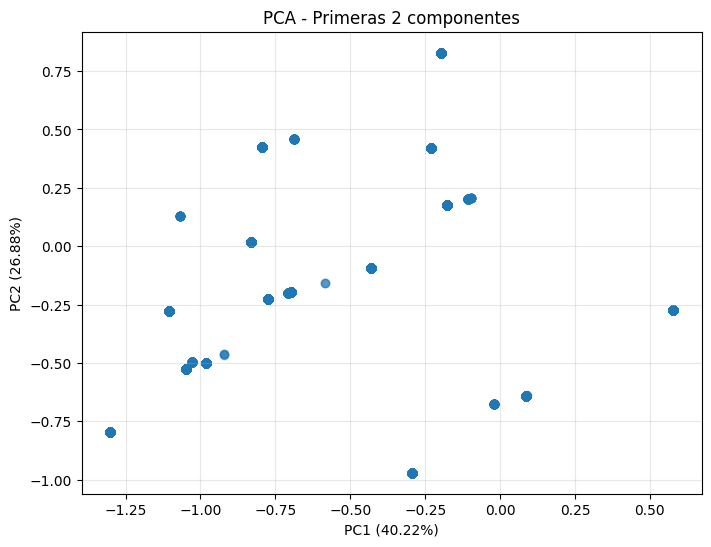

In [124]:
categoricas = df[['market_segment', 'distribution_channel']]
matriz = pd.get_dummies(categoricas, columns=['market_segment', 'distribution_channel'])
matriz

pca = PCA(n_components=13)
X_pca = pca.fit_transform(matriz)

print(f"Varianza explicada por cada componente:")
for i, var in enumerate(pca.explained_variance_ratio_[:5], 1):
    print(f"  PC{i}: {var:.4f} ({var*100:.2f}%)")
print(f"\nVarianza explicada acumulada (primeras 2 PCs): {pca.explained_variance_ratio_[:2].sum():.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA - Primeras 2 componentes')
plt.grid(True, alpha=0.3)
plt.show()


# 4) Modelo lineal (LinearRegression) para `adr`
- Selecciona 3–6 features razonables (numéricas + 1 categórica one-hot).  
- Split train/test simple.  
- Métricas: **RMSE** y **R²**.


Shape de X_train: (95512, 6)
Shape de X_test: (23878, 6)
Features utilizadas: ['lead_time', 'adults', 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_of_special_requests', 'hotel_Resort Hotel']

=== Resultados del Modelo de Regresión Lineal ===

TRAIN:
  RMSE: 48.6084
  R²: 0.0984

TEST:
  RMSE: 45.3559
  R²: 0.1005

=== Coeficientes del modelo (todas las features estandarizadas) ===
                     Feature  Coeficiente
5         hotel_Resort Hotel    -0.281422
1                     adults     0.221270
4  total_of_special_requests     0.132351
0                  lead_time    -0.100629
3       stays_in_week_nights     0.074517
2    stays_in_weekend_nights     0.013316

Intercepto: 0.0941


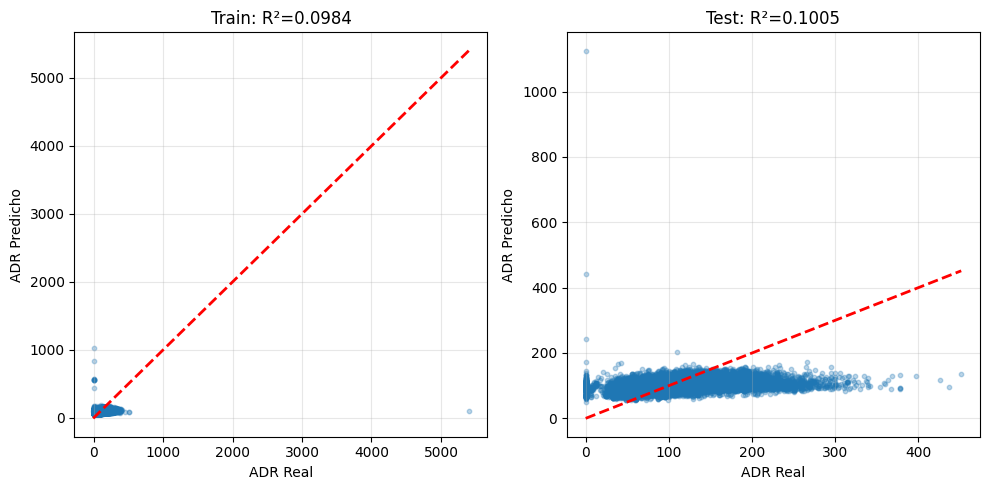

In [125]:
# Seleccionamos features numéricas y categóricas
from sklearn.model_selection import train_test_split

# Eliminamos filas con valores nulos en las columnas relevantes
df_clean = df.dropna(subset=['adr', 'lead_time', 'adults', 'stays_in_weekend_nights', 
                               'stays_in_week_nights', 'total_of_special_requests', 'hotel'])

# Features numéricas
features_numericas = ['lead_time', 'adults', 'stays_in_weekend_nights', 
                      'stays_in_week_nights', 'total_of_special_requests']

# Feature categórica: hotel (City Hotel vs Resort Hotel)
features_categoricas = ['hotel']

# Preparamos X con numéricas
X_numericas = df_clean[features_numericas]

# One-hot encoding para la variable categórica 'hotel'
X_categoricas = pd.get_dummies(df_clean[features_categoricas], drop_first=True)

# Combinamos features numéricas y categóricas
X = pd.concat([X_numericas, X_categoricas], axis=1)

# Variable objetivo
y = df_clean['adr']

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Estandarizamos las features numéricas
scaler_X = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Escalamos solo las columnas numéricas de X
X_train_scaled[features_numericas] = scaler_X.fit_transform(X_train[features_numericas])
X_test_scaled[features_numericas] = scaler_X.transform(X_test[features_numericas])

# Escalamos también la variable objetivo y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"Shape de X_train: {X_train_scaled.shape}")
print(f"Shape de X_test: {X_test_scaled.shape}")
print(f"Features utilizadas: {list(X.columns)}")

# Entrenamos el modelo de regresión lineal con datos escalados
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_scaled, y_train_scaled)

# Predicciones (escaladas)
y_pred_train_scaled = modelo_lineal.predict(X_train_scaled)
y_pred_test_scaled = modelo_lineal.predict(X_test_scaled)

# Des-escalamos las predicciones a la escala original
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).ravel()
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()

# Métricas en train (escala original)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Métricas en test (escala original)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n=== Resultados del Modelo de Regresión Lineal ===")
print(f"\nTRAIN:")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  R²: {r2_train:.4f}")

print(f"\nTEST:")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R²: {r2_test:.4f}")

# Coeficientes del modelo (en escala estandarizada, comparables entre sí)
print("\n=== Coeficientes del modelo (todas las features estandarizadas) ===")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_lineal.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coef_df)
print(f"\nIntercepto: {modelo_lineal.intercept_:.4f}")

# Visualización: valores reales vs predichos (escala original)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.3, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('ADR Real')
plt.ylabel('ADR Predicho')
plt.title(f'Train: R²={r2_train:.4f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('ADR Real')
plt.ylabel('ADR Predicho')
plt.title(f'Test: R²={r2_test:.4f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) GLM Binomial — LogisticRegression + OneHotEncoder (ROC-AUC)
- `y = is_canceled`.  
- `X` con numéricas y categóricas (OneHot); evalúa con **ROC-AUC**.  
- Dibuja la **curva ROC**.


In [126]:
df = df.dropna().reset_index()

In [ ]:
# Seleccionamos features numéricas y categóricas
from sklearn.model_selection import train_test_split

# Separamos variables numéricas y categóricas (excluyendo is_canceled de las features)
numericas = df.select_dtypes(include=('number')).columns.drop(['is_canceled', 'index'])
categoricas = df.select_dtypes(include=('object')).columns

# Variable objetivo
y = df['is_canceled']

# Features numéricas y categóricas
X_numericas = df[numericas]
X_categoricas = df[categoricas]

print(f"Variables numéricas ({len(numericas)}): {list(numericas)[:10]}...")
print(f"Variables categóricas ({len(categoricas)}): {list(categoricas)[:5]}...")
print(f"\nShape de X_numericas: {X_numericas.shape}")
print(f"Shape de X_categoricas: {X_categoricas.shape}")
print(f"Shape de y: {y.shape}")

# Seleccionamos algunas features relevantes (para no tener demasiadas después del OneHot)
features_num_seleccionadas = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month',
                               'stays_in_weekend_nights', 'stays_in_week_nights', 
                               'adults', 'children', 'babies', 'adr', 
                               'total_of_special_requests']

features_cat_seleccionadas = ['hotel', 'market_segment', 'distribution_channel', 
                               'deposit_type', 'customer_type']

X_num_sel = df[features_num_seleccionadas]
X_cat_sel = df[features_cat_seleccionadas]

# One-Hot encoding para las categóricas
X_cat_encoded = pd.get_dummies(X_cat_sel, drop_first=True)

# Combinamos numéricas y categóricas
X = pd.concat([X_num_sel, X_cat_encoded], axis=1)

print(f"\n=== Features finales ===")
print(f"Shape de X final: {X.shape}")
print(f"Columnas: {list(X.columns)[:10]}...")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

print(f"\nShape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Distribución de y_train: {y_train.value_counts().to_dict()}")
print(f"Distribución de y_test: {y_test.value_counts().to_dict()}")

# Estandarizamos solo las features numéricas
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_num_seleccionadas] = scaler.fit_transform(X_train[features_num_seleccionadas])
X_test_scaled[features_num_seleccionadas] = scaler.transform(X_test[features_num_seleccionadas])

# Entrenamos el modelo de regresión logística
modelo_logistico = LogisticRegression(max_iter=1000, random_state=random_state)
modelo_logistico.fit(X_train_scaled, y_train)

# Predicciones
y_pred_train = modelo_logistico.predict(X_train_scaled)
y_pred_test = modelo_logistico.predict(X_test_scaled)

# Probabilidades para el ROC-AUC
y_pred_proba_train = modelo_logistico.predict_proba(X_train_scaled)[:, 1]
y_pred_proba_test = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

# Métricas: ROC-AUC
roc_auc_train = roc_auc_score(y_train, y_pred_proba_train)
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)

print("\n=== Resultados del Modelo de Regresión Logística ===")
print(f"\nROC-AUC Score:")
print(f"  Train: {roc_auc_train:.4f}")
print(f"  Test: {roc_auc_test:.4f}")

# Accuracy adicional
from sklearn.metrics import accuracy_score, classification_report
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nAccuracy:")
print(f"  Train: {acc_train:.4f}")
print(f"  Test: {acc_test:.4f}")

# Curva ROC
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
RocCurveDisplay.from_estimator(modelo_logistico, X_train_scaled, y_train)
plt.title(f'Curva ROC - Train (AUC={roc_auc_train:.4f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(modelo_logistico, X_test_scaled, y_test)
plt.title(f'Curva ROC - Test (AUC={roc_auc_test:.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Top 10 coeficientes más importantes (en valor absoluto)
print("\n=== Top 10 Features más importantes (valor absoluto) ===")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coef_df.head(10))

# 6) KMeans + Codo + Silhouette (como en 2024)
- Prepara `X_cluster` con numéricas (`lead_time`, `stays_*_nights`, `adr`, ...).  
- Estandariza (`StandardScaler`).  
- Calcula **inertia** para varios `k` (codo) y **silhouette**.  
- Ajusta KMeans con `k` razonable y perfila cada cluster (medias por variable).


In [ ]:
# Preparamos X_cluster con variables numéricas relevantes
# Seleccionamos features numéricas para clustering
features_cluster = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
                    'adults', 'children', 'babies', 'adr', 
                    'total_of_special_requests', 'arrival_date_week_number',
                    'arrival_date_day_of_month', 'booking_changes']

# Creamos el dataset para clustering (eliminando NaN si hay)
X_cluster = df[features_cluster].dropna()

print(f"=== Dataset para Clustering ===")
print(f"Shape de X_cluster: {X_cluster.shape}")
print(f"Features utilizadas: {features_cluster}")
print(f"\nEstadísticas descriptivas:")
print(X_cluster.describe())

# Estandarizamos los datos (IMPORTANTE para KMeans)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"\n=== Datos estandarizados ===")
print(f"Shape de X_cluster_scaled: {X_cluster_scaled.shape}")

# ==========================================
# MÉTODO DEL CODO (Elbow Method)
# ==========================================
print("\n=== Calculando método del codo (inertia) ===")

k_range = range(2, 11)  # Probamos de k=2 hasta k=10
inertias = []
silhouette_scores = []

for k in k_range:
    print(f"Probando k={k}...", end=" ")
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    kmeans.fit(X_cluster_scaled)
    
    inertia = kmeans.inertia_
    inertias.append(inertia)
    
    # Calculamos silhouette score
    silhouette = silhouette_score(X_cluster_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette)
    
    print(f"Inertia: {inertia:.2f}, Silhouette: {silhouette:.4f}")

# Visualizamos el método del codo y silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Método del codo (Inertia)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Método del Codo - KMeans', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)

# Gráfico 2: Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por número de clusters', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)
axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Umbral 0.5')
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================================
# AJUSTE FINAL CON K RAZONABLE
# ==========================================
# Basándonos en los gráficos, elegimos k (típicamente entre 3-5)
# Vamos a elegir el k con mejor silhouette score
k_optimo = list(k_range)[np.argmax(silhouette_scores)]

print(f"\n=== K óptimo seleccionado: {k_optimo} ===")
print(f"Silhouette Score: {max(silhouette_scores):.4f}")

# Entrenamos KMeans con el k óptimo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=random_state, n_init=10)
clusters = kmeans_final.fit_predict(X_cluster_scaled)

# Añadimos los clusters al DataFrame original
X_cluster['cluster'] = clusters

print(f"\nDistribución de observaciones por cluster:")
print(X_cluster['cluster'].value_counts().sort_index())

# ==========================================
# PERFILADO DE CLUSTERS
# ==========================================
print("\n=== PERFILADO DE CLUSTERS (medias por variable) ===\n")

cluster_profile = X_cluster.groupby('cluster')[features_cluster].mean()
print(cluster_profile.T)

# Visualización del perfilado (heatmap)
plt.figure(figsize=(12, 8))
import seaborn as sns
sns.heatmap(cluster_profile.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Valor medio'})
plt.title(f'Perfil de los {k_optimo} Clusters - Medias por Variable', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

# Estadísticas detalladas por cluster
print("\n=== Descripción detallada de cada cluster ===\n")
for i in range(k_optimo):
    cluster_data = X_cluster[X_cluster['cluster'] == i]
    print(f"\n{'='*60}")
    print(f"CLUSTER {i} - {len(cluster_data)} observaciones ({len(cluster_data)/len(X_cluster)*100:.1f}%)")
    print(f"{'='*60}")
    print(cluster_data[features_cluster].describe().T[['mean', 'std', 'min', 'max']])

# Visualización 2D con PCA para ver la separación de clusters
print("\n=== Visualización de clusters en 2D (usando PCA) ===")
pca_cluster = PCA(n_components=2)
X_pca_cluster = pca_cluster.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_cluster[:, 0], X_pca_cluster[:, 1], 
                     c=clusters, cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_cluster.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_cluster.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title(f'Visualización de {k_optimo} Clusters en espacio PCA 2D', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Añadimos los centroides
centroids_pca = pca_cluster.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidths=2,
           label='Centroides')
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== ANÁLISIS COMPLETADO ===")
print(f"Se identificaron {k_optimo} clusters con silhouette score de {max(silhouette_scores):.4f}")

# 7) (Opcional) ElasticNet y/o utilidades 2024
- Entrena **ElasticNet** para `adr` (CV rápida sobre `alpha`/`l1_ratio`).  
- Muestra mejores hiperparámetros y métricas.  
- Extra: convierte una columna booleana a string ("yes"/"no") y filtra **solo numéricas** para un cálculo.
